In [1]:
import numpy as np

# --- grid setup ---

#this is the fineness of the grid 
Nx, Ny = 128, 128
Lx, Ly = 6.0, 6.0   # physical size
dx, dy = Lx / Nx, Ly / Ny

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='xy')

# --- chiral sawblade radius function ---
def chiral_radius(phi, t, n_teeth, R_min, R_max, omega, phase0):
    """
    phi: angle array (rad)
    t: scalar time
    n_teeth: number of teeth (e.g. 3)
    R_min, R_max: inner/outer radius
    omega: rotation speed (can be negative)
    phase0: initial phase
    """
    psi = n_teeth * (phi - omega * t - phase0)
    psi_mod = np.mod(psi, 2 * np.pi)          # wrap to [0, 2pi)
    u = psi_mod / (2 * np.pi)                 # [0, 1)
    return R_min + (R_max - R_min) * u        # linear ramp (sawtooth)

# Returns true or false 
def particle_occupancy(X, Y, cx, cy, t,
                       n_teeth, R_min, R_max, omega, phase0):
    """
    Returns a boolean mask of grid cells occupied by the rotating chiral particle.
    X, Y: coordinates of the point
    cx, cy: particle center
    other paramaters: see chiral_radius
    """
    xr = X - cx
    yr = Y - cy
    r = np.sqrt(xr**2 + yr**2)
    phi = np.arctan2(yr, xr)

    # Here the chiral radius is used
    r_bound = chiral_radius(phi, t, n_teeth, R_min, R_max, omega, phase0)
    # You map all points to radial locations with respect to center, then you check for occupancy
    return r <= r_bound

# Returns the normal vector to the colliding surfaces
def get_surface_normal(x_col, y_col, cx, cy, t, n_teeth, R_min, R_max, omega, phase0):
    """
    Calculates the outward unit normal vector, correctly handling 
    both the 'Ramp' (curved) and 'Flat' (radial drop) sides of the sawblade.
    X, Y: coordinates of the point
    cx, cy: particle center
    other paramaters: see chiral_radius
    """
    # 1. Local Coordinates
    delt_x = x_col - cx
    delt_y = y_col - cy
    r = np.sqrt(delt_x**2 + delt_y**2)
    phi = np.arctan2(delt_y, delt_x) # Result is in (-pi, pi]

    # 2. Analyze the Phase to find distances
    # Calculate current phase 'psi' to determine where we are in the tooth pattern
    psi = n_teeth * (phi - omega * t - phase0)
    psi_mod = np.mod(psi, 2 * np.pi)  # [0, 2pi)
    
    # --- A. Calculate 'Ramp' Normal Strategy ---
    # The ramp normal depends on the slope dR/dphi
    slope_magnitude = (R_max - R_min) * n_teeth / (2 * np.pi)
    
    # Standard Polar Basis Vectors at (x_col, y_col)
    r_hat_x, r_hat_y = np.cos(phi), np.sin(phi)
    phi_hat_x, phi_hat_y = -np.sin(phi), np.cos(phi)
    
    # Normal to the spiral ramp: n = r_hat - (1/r) * (dR/dphi) * phi_hat
    # (Unnormalized)
    nx_ramp = r_hat_x - (slope_magnitude / r) * phi_hat_x
    ny_ramp = r_hat_y - (slope_magnitude / r) * phi_hat_y
    
    # Distance to the ramp boundary (Radial distance)
    u = psi_mod / (2 * np.pi)
    r_bound = R_min + (R_max - R_min) * u
    dist_ramp = np.abs(r - r_bound)


    # --- B. Calculate 'Flat Side' Normal Strategy ---
    # The flat side is a radial wall. Its normal is purely azimuthal (phi_hat).
    # We need to find the angle of the NEAREST tooth wall.
    # The walls occur where psi_mod jumps from 2pi to 0. 
    # This corresponds to psi_mod being close to 0 or 2pi.
    
    # Distance in phase space to the nearest jump (0 or 2pi)
    dist_phase_to_wall = np.min([psi_mod, 2*np.pi - psi_mod])
    
    # Convert phase distance to physical arc length: s = r * d_phi
    # d_phi = d_psi / n_teeth
    dist_flat = r * (dist_phase_to_wall / n_teeth)

    # --- C. Compare and Select ---
    
    if dist_flat < dist_ramp:       
        nx, ny = phi_hat_x, phi_hat_y
        
    else:
        # CASE: We are on the standard "Ramp".
        nx, ny = nx_ramp, ny_ramp

    # Normalize the final vector
    norm = np.sqrt(nx**2 + ny**2)
    return nx / norm, ny / norm


# This simulates a single scattering event
def simulate_one_trial(y1, y2, rotation_frequency_bias, v_x=1.0,
                       n_teeth=3, R_min=1.0, R_max=2.0,
                       t_max=6.0, dt=0.02):
    """
    Run a single trial for the given initial data.
    y1, y2: initial y coordinates of particles 1 and 2
    rotation_frequency_bias: bias in the Maxwell-Boltzmann distribution for angular velocity
        in units of the characteristic frequency sqrt(2kT/I), where I is moment of inertia
    v_x: initial relative velocity in simulation time
    n_teeth, R_min, R_max: particle shape, see chiral_radius above
    t_max: simulation time
    dt: simulation timestep
    """
    #Calculate mass and moment of inertia of a single particle
    #Assume mass density=1
    occ_aux = particle_occupancy(X, Y, 2.5, 2.5, 0,
                                  n_teeth, R_min, R_max, 0, 0)
    mass = np.sum(occ_aux) * dx * dy
    r_sq = (X - 2.5)**2 + (Y - 2.5)**2
    inertia = np.sum(r_sq * occ_aux) * dx * dy
    
    # Particle 1 initial center and velocity
    # Always starts at x=0
    # Initial motion is horizontal and opposite for the 2 particles
    cx1 = 0.75    
    cy1 = y1
    vx1 = v_x/2.0
    vy1 = 0.0
    
    # Particle 2 initial center and velocity
    # Always starts at x=6
    cx2 = 5.25
    cy2 = y2
    vx2 = -v_x/2.0
    vy2 = 0.0

    # Characteristic frequency given by sqrt(2kT/I), where I is moment of inertia
    # Assume kT=1
    omega_scale = np.sqrt(2.0/inertia)
    
    # Random initial phases
    phase1 = np.random.uniform(0, 2*np.pi)
    phase2 = np.random.uniform(0, 2*np.pi)
    # Relative velocity and angular velocities generated from the biased Boltzmann distribution. Assuming kT=1.
    vx_init = np.random.rayleigh(scale=np.sqrt(2.0/mass))
    omega1_init = np.random.normal(loc=rotation_frequency_bias*omega_scale,scale=1.0/np.sqrt(inertia))
    omega2_init = np.random.normal(loc=rotation_frequency_bias*omega_scale,scale=1.0/np.sqrt(inertia))
    # We rescale simulation time units such that always vx=1. This enforces rescaling rotation frequencies
    # Avoids particles being too slow to collide in time t_max or too fast to resolve the collision in timestep dt
    omega1 = omega1_init/vx_init
    omega2 = omega2_init/vx_init
    # High rotation frequencies drawn from the distribution can make collision too fast to resolve in timestep dt
    # We set the rotation frequency cutoff at 0.1 radians per timestep dt. If not satisfied, draw again
    while abs(omega1)>0.1/dt or abs(omega2)>0.1/dt:
        omega1_init = np.random.normal(loc=rotation_frequency_bias*omega_scale,scale=1.0/np.sqrt(inertia))
        omega2_init = np.random.normal(loc=rotation_frequency_bias*omega_scale,scale=1.0/np.sqrt(inertia))
        omega1 = omega1_init/vx_init
        omega2 = omega2_init/vx_init

    #Initial conditions chosen, initialize time
    t = 0.0

    if_collision = 0 # tracks if collision takes place at all
    
    while t <= t_max:
        cx1 += vx1*dt
        cy1 += vy1*dt
        cx2 += vx2*dt
        cy2 += vy2*dt

        occ1 = particle_occupancy(X, Y, cx1, cy1, t,
                                  n_teeth, R_min, R_max, omega1, phase1)
        occ2 = particle_occupancy(X, Y, cx2, cy2, t,
                                  n_teeth, R_min, R_max, omega2, phase2)

        # 1. Detect Overlap
        # Multiply to find intersection (True where both are True)
        collision_mask = occ1 & occ2 
        
        if np.any(collision_mask):
            
            # 2. Find Place of Collision
            # Get indices of all colliding pixels
            # Note: indexing='xy' means Y corresponds to axis 0, X to axis 1
            j_indices, i_indices = np.where(collision_mask)
            
            # Take the average position of all overlapping pixels to find the centroid of collision
            # (Using just the first point [0] is also valid for single-pixel contact)
            i_center = np.mean(i_indices).astype(int)
            j_center = np.mean(j_indices).astype(int)
            
            x_coll = x[i_center]
            y_coll = y[j_center]
            
            # 3. Calculate Distance to Center of Particle 1 and Particle 2
            r1_sq = (x_coll - cx1)**2 + (y_coll - cy1)**2
            r2_sq = (x_coll - cx2)**2 + (y_coll - cy2)**2
            
            normal_x, normal_y = 0.0, 0.0

            # Determine which particle to use for the calculation of the normal to the surface of collision.
            # We take the one with the smaller distance to collision to avoid the singularity at the "tip".
            if r1_sq >= r2_sq:
                # Case A: Collision is closer to the tip of Particle 1. 
                # Use Particle 2's surface normal and invert it (Newton's 3rd law direction).
                nx_2, ny_2 = get_surface_normal(x_coll, y_coll, cx2, cy2, t, 
                                                n_teeth, R_min, R_max, omega2, phase2)
                normal_x, normal_y = -nx_2, -ny_2
            else:
                # Case B: Standard collision on the "ramp" of Particle 1.
                nx_1, ny_1 = get_surface_normal(x_coll, y_coll, cx1, cy1, t, 
                                                n_teeth, R_min, R_max, omega1, phase1)
                normal_x, normal_y = nx_1, ny_1

            #Calculating lever arm for the two particles. It expresses the ratio between the torque and the linear force
            lever_arm1 = normal_x*(y_coll-cy1)-normal_y*(x_coll-cx1)
            lever_arm2 = -normal_x*(y_coll-cy2)+normal_y*(x_coll-cx2)

            # Relative velocity along the normal to colliding surface
            v_rel_normal = (vx1 - vx2) * normal_x + \
                           (vy1 - vy2) * normal_y - \
                           omega1 * lever_arm1 - \
                           omega2 * lever_arm2
            if v_rel_normal < 0:
                # Particles are overlapping but moving away from each other. 
                # Do nothing and let them exit the collision zone.
                pass 
            else:
                if_collision = 1.0
                #Modify velocities
                Delta_p1 = (v_rel_normal)/(1.0/mass+(lever_arm1**2+lever_arm2**2)/2.0/inertia)
                vx1 -= Delta_p1*normal_x/mass
                vy1 -= Delta_p1*normal_y/mass
                vx2 += Delta_p1*normal_x/mass
                vy2 += Delta_p1*normal_y/mass
    
                #Modify angular velocities
                omega1new = omega1+lever_arm1*Delta_p1/inertia
                omega2new = omega2+lever_arm2*Delta_p1/inertia
                #Need to correct the phase for consistency!
                phase1 = phase1 + omega1*t -omega1new*t
                phase2 = phase2 + omega2*t -omega2new*t
                omega1 = omega1new
                omega2 = omega2new
        
        t += dt

    return {
            "collision": if_collision,
            "velocity1": (vx_init*vx1, vx_init*vy1),
            "velocity2": (vx_init*vx2, vx_init*vy2),
            "vx_init": vx_init,
            "omega1_init": omega1_init,
            "omega2_init": omega2_init,
            "omega1": vx_init*omega1,
            "omega2": vx_init*omega2,
            "mass": mass,
            "moment_of_inertia": inertia
        }


#Calculating the differential cross section from a number of runs
def cross_section_total(y1,y2, init_frequency_bias,
                                   n_trials=1000, no_of_bins=50,
                                   **sim_kwargs):
    """
    y1, y2: initial y coordinates of particles 1 and 2
    init_frequency_bias: bias in the Maxwell-Boltzmann distribution for angular velocity
        in units of the characteristic frequency sqrt(2kT/I), where I is moment of inertia
    n_trials: number of runs
    no_of_bins: how many bins for the histogram of scattering angles
    """
    # Arrays of all scattering angles and corresponding probability weights
    angles = np.zeros(n_trials)
    weights = np.zeros(n_trials)
    sum_of_weights = 0

    for i in range(n_trials):
        result = simulate_one_trial(y1,y2, rotation_frequency_bias=init_frequency_bias, **sim_kwargs)
        vx1, vy1 = result["velocity1"]
        vx2, vy2 = result["velocity2"]
        inertia = result["moment_of_inertia"]
        weight = result["collision"]      
        weights[i] = weight
        vx_rel = vx2-vx1
        vy_rel = vy2-vy1
        if weight == 0:
            angles[i] = np.pi
        else:
            angles[i] = np.arctan2(vy_rel,vx_rel)
          
    sum_of_weights = np.sum(weights)
    return {
            "scattering_angles": angles,
            "if_collision": weights
    }


In [2]:
#The impact parameters go from -4.0 to 4.0
no_of_Dy_values = 40 #How many impact parameters
trials_per_Dy = 1000 #Runs per impact parameter
no_of_bins = 50 #Number of bins for scattering angle histogram
rotation_bias = 0.2 #Bias of the MB distribution for rotations in units of characteristic thermal frequency

y1_values = np.linspace(-4.0, 4.0, no_of_Dy_values+1)
Delta_b = 8.0/(1.0*no_of_Dy_values)
Delta_Theta = 2*np.pi/(1.0*no_of_bins)

print("{Impact parameter, number of collisions}")

angles_all = []
weights_all = []
for Dy in y1_values:
    result = cross_section_total(1.0+(Dy+4.0)/2.0,5.0-(Dy+4.0)/2.0,init_frequency_bias=rotation_bias,n_trials=trials_per_Dy)
    angles = result["scattering_angles"]
    weights = result["if_collision"]
    angles_all.append(angles)
    weights_all.append(weights)
    sum_of_weights = np.sum(weights)
    print(f"{{{Dy:.2f}, {sum_of_weights:.0f}}},")
    
weights_total = np.sum(weights_all)
weights_all = np.asarray(weights_all) #So we can use matrix operations
# cross_section = weights_all*Delta_b/(Delta_Theta*trials_per_Dy) # differential cross section array
cross_section = weights_all*Delta_b/trials_per_Dy/Delta_Theta # differential cross section array
bins = np.linspace(-np.pi, np.pi, no_of_bins+1)
hist, bin_edges = np.histogram(angles_all, bins=bins, weights=cross_section)
print("The differential cross section histogram:")
print(hist)

{Impact parameter, number of collisions}
{-4.00, 0},
{-3.80, 252},
{-3.60, 518},
{-3.40, 744},
{-3.20, 921},
{-3.00, 991},
{-2.80, 1000},
{-2.60, 1000},
{-2.40, 1000},
{-2.20, 1000},
{-2.00, 1000},
{-1.80, 1000},
{-1.60, 1000},
{-1.40, 1000},
{-1.20, 1000},
{-1.00, 1000},
{-0.80, 1000},
{-0.60, 1000},
{-0.40, 1000},
{-0.20, 1000},
{0.00, 1000},
{0.20, 1000},
{0.40, 1000},
{0.60, 1000},
{0.80, 1000},
{1.00, 1000},
{1.20, 1000},
{1.40, 1000},
{1.60, 1000},
{1.80, 1000},
{2.00, 1000},
{2.20, 1000},
{2.40, 1000},
{2.60, 1000},
{2.80, 998},
{3.00, 996},
{3.20, 955},
{3.40, 806},
{3.60, 573},
{3.80, 268},
{4.00, 0},
The differential cross section histogram:
[0.19098593 0.17507044 0.17029579 0.29761974 0.33581693 0.45677469
 0.50452117 0.61433808 0.76076063 0.8276057  0.86421134 0.92628177
 1.09021136 1.12840855 1.27323954 1.30029589 1.34804237 1.48650717
 1.45945083 1.54698605 1.68545085 1.68226775 1.67908465 1.75070437
 1.83983114 1.91304242 1.73638043 1.81754945 1.84142269 1.84460579
 1.77

Effective radius for one chirality: 1.63
Effective radius for the other chirality: 1.95
d=1.79
ε=0.09


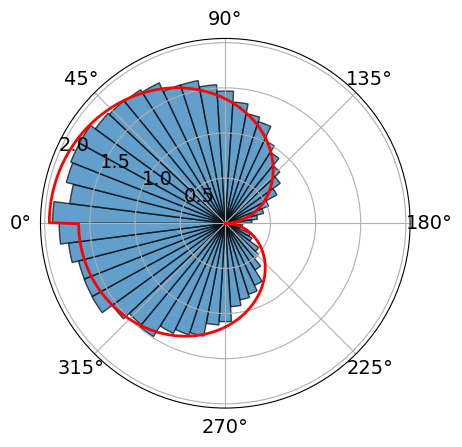

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Assuming you already have 'hist' and 'bin_edges' from np.histogram
# Calculate centers and widths

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = np.diff(bin_edges)

# Fitting to the toy model differential scattering cross section.
def fitfunc(angle, diameter):
    return diameter*np.sin(angle/2.0)

dopt1, dcov1 = curve_fit(fitfunc,(bin_centers+np.pi)[:int(len(bin_centers)/2)],hist[:int(len(hist)/2)])
dopt2, dcov2 = curve_fit(fitfunc,(bin_centers+np.pi)[int(len(bin_centers)/2):],hist[int(len(hist)/2):])
d1 = dopt1[0]
d2 = dopt2[0]
print(f"Effective radius for one chirality: {d1:.2f}")
print(f"Effective radius for the other chirality: {d2:.2f}")

d = (d1+d2)/2.0
epsilon = (d2-d1)/(2.0*d)
print(f"d={d:.2f}")
print(f"ε={epsilon:.2f}")

# 1. Create a smooth range of angles for the curve (e.g., 1000 points)
theta_fit = np.linspace(0, 2*np.pi, 1000)
ToPlot = d1*np.sin(theta_fit/2.0) #Scattering cross section of the toy model
for i in range(len(ToPlot)):
    if i >= len(ToPlot)/2:
        ToPlot[i] = d2*np.sin(theta_fit[i]/2.0)
        
# Create the polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Plot the bars: 
# x = bin_centers (where the bar sits)
# height = hist (how far out it goes)
ax.bar(bin_centers, hist, width=bin_width, edgecolor='black', alpha=0.7)
ax.plot(theta_fit+np.pi, ToPlot, color='red', lw=2, label='Fitted Model')

# Set the radial ticks (y-axis equivalent in polar) to every 0.50 up to 2.0
ax.set_rticks([0.5, 1.0, 1.5, 2.0])

# Increase the font size for both the angular (degrees) and radial (0.5, 1.0...) ticks
# Adjust 'labelsize' up or down to find what looks best for your figure
ax.tick_params(axis='both', labelsize=14)

# Optional: Adjust the starting direction (e.g., North/Top for 0 degrees)
ax.set_theta_zero_location("W")
# Optional: Change direction to clockwise
ax.set_theta_direction(-1) 

plt.savefig('scattering_fit_rotation02.png')